# 第 5 章 逻辑回归（Logistic Regression）

逻辑回归是最常用的**二分类模型**之一，也是很多深度学习模型的基础模块。本章从定义开始，一步步到损失函数、多分类扩展，再到完整案例。

## 5.1 逻辑回归简介

### 5.1.1 什么是逻辑回归

逻辑回归是用来**预测某个事件发生的概率**的模型，特别适合 **0/1 二分类** 问题。
它先做一次**线性回归**，再把结果丢进一个 **S 形的函数（sigmoid）**，把值压到区间 $[0, 1]$ 里，当作“属于正类的概率”。

#### 1. sigmoid 函数

逻辑回归常用的映射函数是 **sigmoid 函数**：

* 函数形式：

  $$
  f(x) = \frac{1}{1 + e^{-x}}
  $$

* 导数（后面做梯度时会用到）：

  $$
  f'(x) = f(x)(1 - f(x))
  $$

**直观理解：**

* $x$ 很大时，$f(x) \approx 1$
* $x$ 很小时，$f(x) \approx 0$
* $x=0$ 时，$f(0) = 0.5$

所以它非常适合拿来表示“某件事发生的概率”。

#### 2. 逻辑回归模型形式

假设特征为 $x = (x_1, x_2, \dots, x_n)^T$，参数为 $\beta = (\beta_0, \beta_1, \dots, \beta_n)^T$，
线性部分为：

$$
z = \beta_0 + \beta_1 x_1 + \cdots + \beta_n x_n = \beta^T x
$$

把 $z$ 丢进 sigmoid：

$$
P(y = 1 \mid x) = \frac{1}{1 + e^{-z}} = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \cdots + \beta_n x_n)}}
$$

这里：

* $P(y = 1 \mid x)$ 表示样本 $x$ 属于“1 类”（正类）的概率。
* $P(y = 0 \mid x) = 1 - P(y = 1 \mid x)$。

#### 3. 从概率到分类结果：阈值

通常我们设置一个**阈值**（threshold），例如 $0.5$：

* 如果 $P(y = 1 \mid x) \ge 0.5$，预测为 **1 类**；
* 否则预测为 **0 类**。

#### 4. 简单代码示例：手工计算 sigmoid 和分类

In [1]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# 假设只有一个特征
beta0 = -1.0
beta1 = 2.0

# 三个样本的特征值
X = np.array([-1.0, 0.0, 2.0])
z = beta0 + beta1 * X
p = sigmoid(z)

print("线性输出 z:", z)
print("概率 p:", p)

# 按阈值 0.5 做分类
y_pred = (p >= 0.5).astype(int)
print("预测类别:", y_pred)

线性输出 z: [-3. -1.  3.]
概率 p: [0.04742587 0.26894142 0.95257413]
预测类别: [0 0 1]


* 对于特征值较小的样本，概率更接近 0，容易被分成 0 类；
* 对于特征值较大的样本，概率更接近 1，容易被分成 1 类。

> 逻辑回归用来回答问题：**“在这个特征条件下，属于某一类别的概率有多大？”**

### 5.1.2 逻辑回归的典型应用场景

逻辑回归只要能把问题拆成“是 / 否”“有 / 没有”等二选一，就能派上用场：

* **信用评分**：是否会违约（违约 / 不违约）
* **欺诈检测**：这笔交易是否是欺诈
* **垃圾邮件检测**：邮件是否是垃圾邮件
* **广告点击预测**：用户是否会点击广告
* **简单图像分类**：是否有猫、是否有肿瘤等二分类
* **情感分析（简化版）**：评论是正面还是负面
* **产品质量检测**：产品是否合格
* **医学诊断**：患者是否患某种疾病
* **生物信息学**：蛋白质是否具备某种功能

**总结：**
只要标签是 **0/1**，逻辑回归都是一个值得先试的基线模型。

### 5.1.3 逻辑回归的损失函数（对数损失）

逻辑回归通常使用 **对数损失（Log Loss）**，也叫 **二元交叉熵损失（Binary Cross-Entropy）**。

#### 1. 条件概率

给定输入 $x$ 和参数 $\beta$，模型输出正类概率：

$$
P(y = 1 \mid x; \beta) = \frac{1}{1 + e^{-\beta^T x}}
$$

$$
P(y = 0 \mid x; \beta) = 1 - P(y = 1 \mid x; \beta)
$$

可以统一写成：

$$
P(y \mid x; \beta) =
\Big(P(y = 1 \mid x; \beta)\Big)^y
\Big(1 - P(y = 1 \mid x; \beta)\Big)^{1 - y}
$$

其中 $y \in {0, 1}$。

#### 2. 似然函数与对数似然

假设有 $n$ 个样本 ${(x_i, y_i)}_{i=1}^n$，并假定样本独立：

$$
L(\beta) = \prod_{i=1}^n P(y_i \mid x_i; \beta)
$$

取对数得到**对数似然**：

$$
\log L(\beta)
= \sum_{i=1}^n \Big[
y_i \log P(y_i = 1 \mid x_i; \beta)
+ (1 - y_i)\log(1 - P(y_i = 1 \mid x_i; \beta))
\Big]
$$

#### 3. 损失函数：负对数似然

训练的目标是 **最大化对数似然**。
等价地，我们最小化其相反数，并加上 $\frac{1}{n}$ 做平均：

$$
\text{Loss}(\beta)
= - \frac{1}{n} \sum_{i=1}^n
\Big[
y_i \log p_i
+ (1 - y_i)\log(1 - p_i)
\Big]
$$

其中 $p_i = P(y_i = 1 \mid x_i; \beta)$。

**直观理解：**

* 真实标签为 1 的样本，模型给出高概率 $p_i$ 会让损失变小；
* 真实标签为 0 的样本，模型给出低概率 $p_i$（即 $1-p_i$ 高）也会让损失变小；
* 预测越“离谱”，损失越大。

> 对数损失衡量“模型给真实标签分配的概率有多高”。

### 5.1.4 损失函数的梯度（了解）

这里给出结果和简单推导思路，方便理解实现中的向量形式。

记：

* $y = (y_1, \dots, y_n)^T$ 为标签向量；
* $p = (p_1, \dots, p_n)^T$ 为预测概率向量；
* 设计矩阵 $X \in \mathbb{R}^{n \times d}$，每行是一个样本 $x_i^T$。

有：

$$
p = \sigma(X \beta) = \frac{1}{1 + e^{-X\beta}}
$$

$$
\text{Loss}(\beta)
= -\frac{1}{n}
\Big(
y^T \log p + (1 - y)^T \log (1 - p)
\Big)
$$

其中 $\log p$ 是对向量逐元素取对数。

对 $\beta$ 求梯度，最后结果为：

$$
\nabla_{\beta}\,\text{Loss}(\beta)
= \frac{1}{n} X^T (p - y)
= \frac{1}{n} X^T\Big(\sigma(X\beta) - y\Big)
$$

**直观理解：**

* $p - y$ 就是“预测概率 - 真实标签”，表示误差；
* $X^T(p - y)$ 把这些误差按特征方向加权求和；
* 优化时参数 $\beta$ 会沿着让误差减小的方向更新。

> 这个梯度公式就是实际中用梯度下降、LBFGS 等算法训练逻辑回归的数学基础。

### 5.1.5 scikit-learn 中的 LogisticRegression 使用

#### 1. 核心参数说明

In [2]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    solver="lbfgs",
    penalty="l2",
    C=1.0,
    class_weight="balanced"
)

常用参数含义：

* `solver`：优化算法

  * `"lbfgs"`：默认，拟牛顿法，适合中小规模数据，支持 `penalty="l2"`
  * `"newton-cg"`：牛顿法，支持 `L2`
  * `"liblinear"`：基于坐标下降，适合小数据集，支持 `L1` 和 `L2`
  * `"sag"`：随机平均梯度，适合大规模数据，只支持 `L2`
  * `"saga"`：改进的随机梯度，适合大规模数据，支持 `L1`、`L2` 和 `elasticnet`
* `penalty`：正则化类型，常用 `"l1"`、`"l2"`、`"elasticnet"`、`"none"`
* `C`：正则化强度的**倒数**（越大正则越弱，越小正则越强）
* `class_weight`：类别权重

  * `None`：每个样本权重相同
  * `"balanced"`：根据类频率自动调整，让少数类权重更大

> 大部分情况下，可以先用默认参数训练一个基线模型，再根据数据规模和类别不平衡情况调整 `solver`、`C` 和 `class_weight`。

#### 2. 案例：心脏病预测（二分类）

Heart Disease数据集：https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset。

目标：根据患者的多种指标，预测“是否患有心脏病”（0 = 否，1 = 是）。

**特征示例：**

* 年龄：连续值
* 性别：0-女，1-男
* 胸痛类型：0-典型心绞痛，1-非典型心绞痛，2-非心绞痛，3-无症状
* 静息血压：连续值，单位mmHg
* 胆固醇：连续值，单位mg/dl
* 空腹血糖：1-大于120mg/dl，0-小于等于120mg/dl
* 静息心电图结果：0-正常，1-ST-T异常，2-可能左心室肥大
* 最大心率：连续值
* 运动性心绞痛：1-有，0-无
* 运动后的ST下降：连续值
* 峰值ST段的斜率：0-向上，1-水平，2-向下
* 主血管数量：0到3
* 地中海贫血：一种先天性贫血，0-正常，1-固定缺陷，2-可逆缺陷
* 是否患有心脏病：标签，0-否，1-是

**代码示例：**

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

# 1. 加载数据
heart_disease = pd.read_csv("data/heart_disease.csv")
heart_disease = heart_disease.dropna()  # 简单丢弃缺失值样本

# 2. 划分特征和标签
X = heart_disease.drop("是否患有心脏病", axis=1)
y = heart_disease["是否患有心脏病"]

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100
)

# 3. 特征工程
numerical_features = ["年龄", "静息血压", "胆固醇", "最大心率", "运动后的ST下降", "主血管数量"]
categorical_features = ["胸痛类型", "静息心电图结果", "峰值ST段的斜率", "地中海贫血"]
binary_features = ["性别", "空腹血糖", "运动性心绞痛"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),       # 数值标准化
        ("cat", OneHotEncoder(drop="first"), categorical_features),  # 类别独热编码
        ("binary", "passthrough", binary_features),          # 二元特征原样保留
    ]
)

x_train = preprocessor.fit_transform(x_train)
x_test = preprocessor.transform(x_test)

# 4. 建模与训练
model = LogisticRegression(max_iter=200)
model.fit(x_train, y_train)

# 5. 模型评估：准确率
score = model.score(x_test, y_test)
print("测试集准确率：", score)

测试集准确率： 0.8441558441558441


* `model.score(x_test, y_test)` 返回的是**预测正确的比例**（accuracy）。
* 如果类别不平衡明显，建议额外看 `precision`、`recall` 等指标。

> 这是典型的医疗二分类预测：输入多维指标，输出“是否患病”的概率。

## 5.2 多分类任务中的逻辑回归

逻辑回归不只可以做 0/1，配合不同策略也可以做 **多分类**：

* 一对多（One-vs-Rest，OvR）
* Softmax 回归（多项逻辑回归，Multinomial Logistic Regression）

### 5.2.1 一对多（OvR）

#### 1. 实现思路

假设有 $C$ 个类别：

* 为每个类别 $c$ 训练一个二分类器：
  “是类别 $c$” vs “不是类别 $c$”；
* 共有 $C$ 个逻辑回归模型；
* 预测时，对每个样本计算这 $C$ 个模型的概率，选取概率最大的类别。

对类别 $c$ 的模型：

$$
P(y = c \mid x; \beta^{(c)}) = \frac{1}{1 + e^{-(\beta^{(c)})^T x}}
$$

对应的损失（对第 $c$ 个模型）与二分类完全一样：

$$
\text{Loss}^{(c)}
= -\frac{1}{n} \sum_{i=1}^n
\Big[
y_i^{(c)} \log P(y_i = c \mid x_i; \beta^{(c)})
+ (1 - y_i^{(c)}) \log\big(1 - P(y_i = c \mid x_i; \beta^{(c)})\big)
\Big]
$$

其中 $y_i^{(c)} = 1$ 表示第 $i$ 个样本的真实类别是 $c$，否则为 $0$。

#### 2. 优缺点

* **优点：**

  * 实现简单，直接复用二分类逻辑回归；
  * 对多数库来说，配置方便。
* **缺点：**

  * 需要训练 $C$ 个模型，类别多时训练开销大；
  * 各个二分类器之间相互独立，概率不一定完全“协调”。

#### 3. scikit-learn 中的 OvR 使用

方式一：直接用 `LogisticRegression` 并指定 `multi_class="ovr"`：

In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(multi_class="ovr")
# model.fit(X_train, y_train)

方式二：用 `OneVsRestClassifier` 包一层：

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

base_clf = LogisticRegression()
model = OneVsRestClassifier(base_clf)
# model.fit(X_train, y_train)

> 类别不算很多、想快速把二分类模型扩展到多分类时，用 OvR 是最顺手的选择。

### 5.2.2 Softmax 回归（多项逻辑回归）

#### 1. 实现思路

Softmax 回归直接用 **一个模型** 同时预测所有类别的概率。

假设有 $C$ 个类别，对每个类别 $c$ 有一组参数向量 $\beta_c$：

* 对每个类别 $c$，先计算一个“分数”：

  $$
  s_c = \beta_c^T x
  $$

* 再用 Softmax 函数转成概率：

  $$
  P(y = c \mid x) =
  \frac{e^{\beta_c^T x}}{\sum_{j=1}^C e^{\beta_j^T x}}
  $$

所有类别的概率之和为 1，是一个完整的分布。

#### 2. 多分类交叉熵损失

对 $n$ 个样本，Softmax 回归的损失函数为：

$$
\text{Loss} =
- \frac{1}{n} \sum_{i=1}^n \sum_{c=1}^C
\mathbf{1}(y_i = c)\, \log P(y_i = c \mid x_i)
$$

其中 $\mathbf{1}(y_i = c)$ 是示性函数：

* 当样本 $i$ 的真实类别是 $c$ 时，$\mathbf{1}(y_i = c) = 1$；
* 否则为 $0$。

**直观理解：**
跟二分类的对数损失类似，只不过现在是真实类别那一维的概率要尽量大。

#### 3. 优缺点

* **优点：**

  * 只训练一个模型，参数共享，计算更高效；
  * 概率输出是一个整体分布，各类别之间“协调性”更好。
* **缺点：**

  * 每次前向计算都要对所有类别求指数和归一化，类别非常多时计算量较大。

#### 4. scikit-learn 中的 Softmax 使用

In [6]:
from sklearn.linear_model import LogisticRegression

# 显式指定多项逻辑回归
model = LogisticRegression(multi_class="multinomial", solver="lbfgs")
# model.fit(X_train, y_train)

在一些版本中，如果目标变量有 3 个及以上类别且使用适合的 `solver`（如 `"lbfgs"`），`LogisticRegression` 也会自动使用多项逻辑回归，因此你也可以简单写：

In [7]:
model = LogisticRegression()  # 多分类时默认就是 multinomial（取决于版本与 solver）
# model.fit(X_train, y_train)

> 多分类且类别不特别夸张时，Softmax 回归通常比 OvR 更自然，也是深度学习分类的标准配置。

## 5.3 案例：手写数字识别（多分类）

### 5.3.1 数据集说明：Digit Recognizer

* 数据来源：Kaggle 竞赛 **Digit Recognizer**
* 每一行是一张 **28×28 灰度图** 展平后的 784 维向量；
* 像素值范围：0–255（0 代表黑，255 代表白）；
* 第一列是标签 `label`（数字 0–9），后面 784 列是像素值。

第 $(x, y)$ 个像素在 CSV 中的位置为：

* 行：某一个样本；
* 列：`1 + x * 28 + y`（第 1 列是标签）。

### 5.3.2 用逻辑回归实现手写数字识别

这里用逻辑回归做一个多分类基线模型。

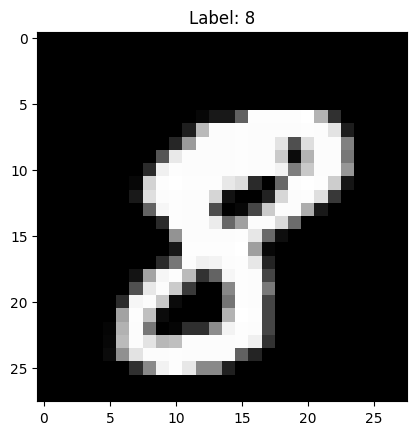

/Users/shenjiuyang/workspace/llm-learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


测试集准确率： 0.9155555555555556


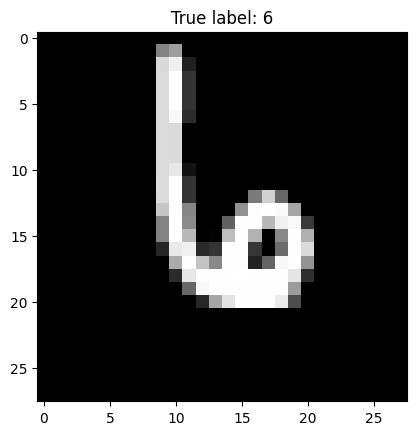

模型预测结果： 6


/Users/shenjiuyang/workspace/llm-learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

# 1. 加载数据
digit = pd.read_csv("data/train.csv")

# 可视化第 10 张图像
plt.imshow(digit.iloc[10, 1:].values.reshape(28, 28), cmap="gray")
plt.title(f"Label: {digit.iloc[10, 0]}")
plt.show()

# 2. 划分特征和标签
X = digit.drop("label", axis=1)  # 784 维像素
y = digit["label"]               # 数字 0–9

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100
)

# 3. 归一化到 [0, 1]，有助于优化收敛
preprocessor = MinMaxScaler()
x_train = preprocessor.fit_transform(x_train)
x_test = preprocessor.transform(x_test)

# 4. 训练多分类逻辑回归
model = LogisticRegression(
    max_iter=500,          # 增大迭代次数
    multi_class="multinomial",
    solver="lbfgs"
)
model.fit(x_train, y_train)

# 5. 模型评估
score = model.score(x_test, y_test)
print("测试集准确率：", score)

# 6. 随机挑一张图预测
idx = 123
plt.imshow(digit.iloc[idx, 1:].values.reshape(28, 28), cmap="gray")
plt.title(f"True label: {digit.iloc[idx, 0]}")
plt.show()

x_single = digit.iloc[idx, 1:].values.reshape(1, -1)
x_single = preprocessor.transform(x_single)
y_pred = model.predict(x_single)
print("模型预测结果：", y_pred[0])

* `score` 一般在一个不错的水平（取决于特征预处理和参数），作为基线模型已经能识别不少数字；
* 逻辑回归在这么高维的原始像素上并不是最强模型，但非常适合用来做：

  * 快速 baseline；
  * 理解多分类 + Softmax 回归的实际表现。

> 这个例子展示了逻辑回归在“高维、多分类”上的用法，是从传统机器学习走向神经网络前的一个很好的中间台阶。